### Agent-based Choice Modeling Based on (S-shaped) Learning 

In [1]:
import numpy as np
import pandas as pd
import math
from numpy import log as ln
import random

import matplotlib.pyplot as plt          
import seaborn as sns

In [11]:
# Both Public Transport Utility ('PT_U') and Feeder Utility ('F_U') are changing in [0,1] interval. 
# While we update 'F_U' based on learning, 'PT_U' is fixed at the interval mean 0.5.
PT_U = 0.5

# When F_U = 0, model gives error. That is why we consider 'min_U' as the minimum value of 'F_U'.
min_U = 0.01

# The utilities in Hanna's model are represented with small 'u'. Feeder utility as 'F_u' and Public Transport as 'PT_u'.

# 'nP' is the number of agents (number of trips in Hanna's model). I set it to 1 for this simple example.
nP = 2

# 'learning_d' determines how fast agents should learn. With a slow learning we are gonna need more iterations.
learning_d = 2

# 'mu' is for the logit model.
mu = 5

# Here I store results of each iteration in 'res'.
res = []

# Number of iterations or number of simulation days is represented by 'n_iteration' 
n_iteration = 10

for iteration in range(0,n_iteration):
    
    # Since Hanna'a loop is not implemented yet, I need a dataframe to start with.
    pax = pd.DataFrame(columns=['pre_F_U', 'F_U', 'PT_U', 'F_u', 'PT_u', 'used_F'], index=pd.Index(range(1, nP+1), name='id'))
    # This is the utility of PT on S-shaped curve (not the one in Hanna's model)
    pax['PT_U'] = 0.5
    # I don't have the PT utilities from Hanna's model, so I fix the seed and choose random utilities.
    np.random.seed(42)
    pax['PT_u'] = np.random.rand(len(pax))
    # Agents can only learn if they use the Feeder. Here for simplicity we assume they use it every day.
    pax['used_F'] = True
    # 'pre_F_U' is the 'F_U' from previous iteration (day). We set it to minimum if we are on iteration zero.
    pax['pre_F_U'] = min_U if iteration == 0 else res[iteration-1].F_U
    # Similar to 'PT_u', 'F_u' is also calculated in Hanna's model. But, here we assume it is one.
    pax['F_u'] = 1
    # Here we calculated the utility difference between PT and F (simply: How good F is?).
    pax['signal_u'] = pax.apply(lambda row: (row.PT_u-row.F_u)/row.PT_u if row.used_F else 0, axis=1)
    # Now, that we know how good F is, we adjust 'F_U'.
    # pax['F_U'] = pax.apply(lambda row: min((1-1e-2), max(1/(1+math.exp(ln((1/row.pre_F_U)-1)+learning_d*row.signal_u)), 1e-2)), axis=1)
    pax['F_U'] = pax.apply(lambda row: min((1-1e-2), max(1/(1+math.exp(ln(1/row.pre_F_U-5)+learning_d*row.signal_u)), 1e-2)), axis=1)

        #    ret_p1.apply(lambda row: min((1-1e-2), max(1/(1+math.exp(ln((1/row.pre_F_U)-1)+learning_d*row.signal_u)), 1e-2)), axis=1)
           # df_sum_sh.apply(lambda row: min((1-1e-2), max(1/(1+math.exp(ln(1 / row.F_U - 1)  +learning_d*row.signal_u)), 1e-2)), axis=1)
    # We use simple binary logit to calculate the probabilities.
    pax['F_P'] = pax.apply(lambda row: (math.exp(mu*row.F_U))/(math.exp(mu*row.F_U)+math.exp(mu*row.PT_U)), axis=1)
    pax['PT_P'] = 1-pax['F_P'] 
    # I store the results in 'res'.
    res.append(pax)

C:\Users\farno\AppData\Local\Temp/ipykernel_17696/594964173.py:44: RuntimeWarning: invalid value encountered in log
  pax['F_U'] = pax.apply(lambda row: min((1-1e-2), max(1/(1+math.exp(ln(1/row.pre_F_U-5)+learning_d*row.signal_u)), 1e-2)), axis=1)


In [18]:
math.exp(ln((1/0.4)-1))

1.5

In [8]:
res[2]

,pre_F_U,F_U,PT_U,F_u,PT_u,used_F,signal_u,F_P,PT_P
id,,,,,,,,,
1,0.889402,0.990000,0.5,1,0.374540,True,-1.669941,0.920561,0.079439
2,0.012276,0.013599,0.5,1,0.950714,True,-0.051841,0.080764,0.919236


In [9]:
U_F = []
X = []
pax_id = 2

for i in range(n_iteration):
    U_F.append(res[i].F_U[pax_id])
    X.append(i)
    

<AxesSubplot:>

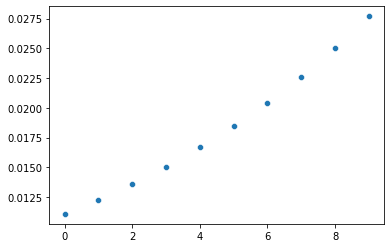

In [10]:
sns.scatterplot(x=X, y=U_F)